In [1]:
import datetime as dt
from functools import partial

import matplotlib as mpl
import numpy as np
import skfda
import xarray as xr
from matplotlib import pyplot as plt
from skfda.representation.basis import BSplineBasis, FourierBasis
from sklearn.model_selection import train_test_split

from src.data_loading import load_data
from src.preprocessing import (
    BasisFunctionTransformer,
    WindowTransformer,
    XArrayStandardScaler,
    time_window_generator,
)
from src.utils import flatten_array

# Setup

For a chosen training window size, we want to generate training samples from a rolling window. Then, we will use each training window of that size to train models for the next 12 months. We will load our RNBS data and focus on estimating the data using only the autoregressive features for now. However, we also have covariates that are important for our final model.


In [2]:
rnbs = load_data("rnbs")
scaler = XArrayStandardScaler()
scaler.fit(rnbs)

train_window_size = 36


training_windows = list(
    time_window_generator(rnbs, train_window_size, 12, reindex_domain=False)
)

train, test = training_windows[-1]

train, test

(<xarray.DataArray 'rnbs' (Date: 36, lake: 4)> Size: 1kB
 array([[   2.942399,   48.82321 ,  101.2149  ,  131.6718  ],
        [  71.16597 ,   99.1696  ,  166.6509  ,  255.5716  ],
        [  60.48264 ,  122.1726  ,  112.8125  ,  260.542   ],
        [ 197.4255  ,  299.6827  ,  288.7482  ,  417.5179  ],
        [ 199.4292  ,  285.3751  ,  215.0817  ,  418.8283  ],
        [ 107.8879  ,  196.7569  ,  229.5701  ,  273.8267  ],
        [ 122.5999  ,   94.20816 ,   26.35805 ,  135.8741  ],
        [  58.84797 ,   -7.334942,  -66.4223  ,    7.003818],
        [ 134.7808  ,  127.1045  ,  -49.99528 ,   37.95617 ],
        [  68.65597 ,   79.30906 ,  -89.61738 ,  128.8702  ],
        [   7.909673,   75.64159 ,   12.24374 ,  149.1135  ],
        [  35.96265 ,  107.732   ,  -27.41238 ,  222.7214  ],
        [  12.75039 ,  129.966   ,  239.3311  ,  334.7825  ],
        [ -29.97239 ,   43.52904 ,   38.46575 ,  163.799   ],
        [  94.15675 ,  170.9958  ,  212.9731  ,  369.8016  ],
        [  89

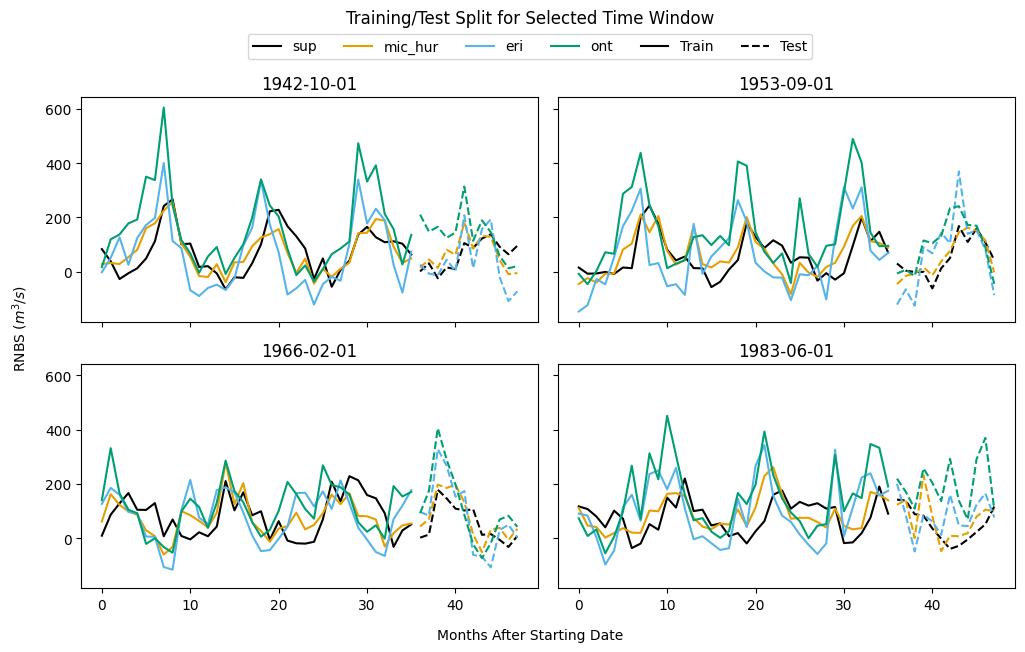

In [3]:
# colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
colors = [
    "#000000",  # black
    "#E69F00",  # orange
    "#56B4E9",  # sky blue
    "#009E73",  # bluish green
]

fig, ax = plt.subplots(figsize=(10, 6), sharex=True, sharey=True, nrows=2, ncols=2)
rng = np.random.default_rng(20250607)
window_idx = np.sort(rng.choice(len(training_windows), size=4, replace=False))
for i, ax_idx in enumerate(ax.flatten()):
    train, test = training_windows[window_idx[i]]
    start_date = np.datetime_as_string(train.coords["Date"].values[0], unit="D")

    for j in range(4):
        ax_idx.plot(
            list(range(36)),
            train[:, j],
            label=train.coords["lake"][j].values,
            color=colors[j],
        )
        ax_idx.plot(list(range(36, 48)), test[:, j], linestyle="--", color=colors[j])

    ax_idx.set_title(start_date)

handles, labels = ax[0, 0].get_legend_handles_labels()
blank_handle = mpl.lines.Line2D([0], [0], color="none", linestyle="")
dataset_handles = [
    mpl.lines.Line2D([0], [0], color="black", linestyle="-"),
    mpl.lines.Line2D([1], [1], color="black", linestyle="--"),
]

# handles = [handles[0], blank_handle, handles[1], dataset_handles[0], handles[2], dataset_handles[1], handles[3]]
handles = [*handles, *dataset_handles]
labels = [*labels, "Train", "Test"]

fig.text(-0.02, 0.5, "RNBS $(m^3/s)$", va="center", rotation="vertical")
fig.text(0.5, -0.02, "Months After Starting Date", ha="center")
fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 1.0), ncol=6)

fig.suptitle("Training/Test Split for Selected Time Window", y=1.03)
fig.tight_layout()

# Data Setup

Once we have all of these training sets, compile them together into a single data object. We have a high dimensional object for multiple lakes, so this should be an $N \times M \times L$ array, where $N$ is the number of training windows, $M$ is training window size, and $L$ is the number of lakes.



In [8]:
# scaled_train_windows, scaled_test_windows = [
#     (scaler.transform(window[0]), scaler.transform(window[1]))
#     for window in zip(
#         *list(time_window_generator(rnbs, train_window_size, 12, reindex_domain=True))
#     )
# ]

list(time_window_generator(rnbs, train_window_size, 12, reindex_domain=True))

CoordinateValidationError: conflicting sizes for dimension 'Date': length 36 on the data but length 37 on coordinate 'Date'

In [8]:
all_data = (
    load_data(["rnbs", "evap", "temp", "precip"])
    .sel(type="Basin")
    .drop("type")
    .to_array()
    .transpose("Date", "lake", ...)
    .dropna("Date")
)

scaler = XArrayStandardScaler()
scaled_data = scaler.fit_transform(all_data)
windower = WindowTransformer(train_size=24, test_size=12, reindex_domain=True)

prior, forecast = windower.fit_transform(scaled_data)

lagged_y = prior.sel(variable=["rnbs"])

lag_fn_transformer = BasisFunctionTransformer(
    default_basis=partial(FourierBasis, n_basis=12),
)

lagged_fn_vals = lag_fn_transformer.fit_transform(lagged_y)

# now get covariates
covariates = forecast.sel(variable=["evap", "temp", "precip"])

/Users/mmcanear/Projects/NBS-Predictor-MVP/src/data_loading/data_loading.py:368: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'Date' ('Date',) The recommendation is to set join explicitly for this case.
  return xr.concat(inputs, dim="type").rename(series)
/Users/mmcanear/Projects/NBS-Predictor-MVP/src/data_loading/data_loading.py:368: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'Date' ('Date',) The recommendation is to set join explicitly for this case.
  return xr.concat(inputs, dim="type").rename(series)
/U

CoordinateValidationError: conflicting sizes for dimension 'Date': length 24 on the data but length 25 on coordinate 'Date'

In [7]:
import numpy as np
from matplotlib import pyplot as plt

y = forecast.sel(variable=["rnbs"])
y_function_transformer = BasisFunctionTransformer(
    default_basis=partial(FourierBasis, n_basis=8, degree=3),
)

y_basis = y_function_transformer.fit_transform(y)


jan_idx = list(range(6, 36 * 25, 12))  # 16 January curves
t = np.arange(0, 12, 1)

fig, axes = plt.subplots(5, 5, figsize=(10, 8), sharex=True, sharey=True)
axes = axes.flatten()

for ax, i in zip(axes, jan_idx):
    # raw observed curve
    arr = y.sel(lake="sup").squeeze()[i].values

    # functional reconstruction
    y_hat = y_function_transformer.basis_lookup["sup"]["rnbs"][i](t)

    ax.plot(t, arr, color="black", linewidth=1.5)
    ax.plot(t, y_hat.squeeze(), color="black", linestyle="--", linewidth=1.5)

    start_date = y.coords["start_date"].values[i]

    ax.set_title(f"{start_date}", fontsize=9)

fig.suptitle("January Curves: Raw (solid) vs Functional Fit (dashed)", fontsize=14)
fig.supxlabel("Time within January")
fig.supylabel("RNBS")

plt.tight_layout()
plt.show()

NameError: name 'forecast' is not defined

In [ ]:
import numpy as np
from matplotlib import pyplot as plt

y = forecast.sel(variable=["rnbs"])

y_function_transformer = BasisFunctionTransformer(
    default_basis=partial(FourierBasis, n_basis=8),
)

y_basis = y_function_transformer.fit_transform(y)


jan_idx = list(range(0, 36 * 25, 12))  # 16 January curves
t = np.arange(0, 12, 1)

fig, axes = plt.subplots(5, 5, figsize=(10, 8), sharex=True, sharey=True)
axes = axes.flatten()

for ax, i in zip(axes, jan_idx):
    # raw observed curve
    arr = y.sel(lake="sup").squeeze()[i].values

    # functional reconstruction
    y_hat = y_function_transformer.basis_lookup["sup"]["rnbs"][i](t)

    ax.plot(t, arr, color="black", linewidth=1.5)
    ax.plot(t, y_hat.squeeze(), color="black", linestyle="--", linewidth=1.5)

    start_date = y.coords["start_date"].values[i]

    ax.set_title(f"{start_date}", fontsize=9)

fig.suptitle("January Curves: Raw (solid) vs Functional Fit (dashed)", fontsize=14)
fig.supxlabel("Time within January")
fig.supylabel("RNBS")

plt.tight_layout()
plt.show()

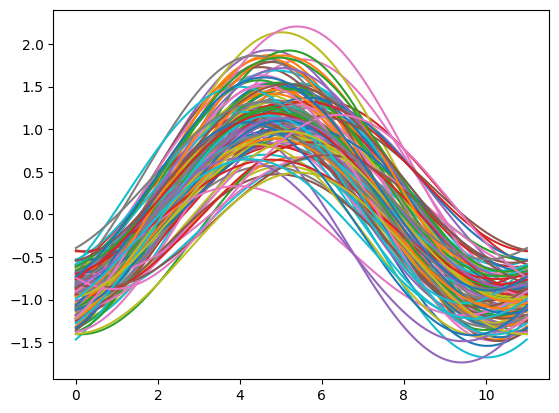

In [ ]:
myplt = forecast_transformer.basis_lookup["sup"]["rnbs"][0::12].plot()

In [119]:
transformed_train.sel(variable="rnbs", lake="sup")[:, -1]

<xarray.DataArray (start_date: 349)> Size: 3kB
array([nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan])
Coordinates:
  * start_date  (start_date) <U10 14kB '1979-01-01' ... '2008-01-01'
    basis_dim   int64 8B 7
    variable    <U4 16B 'rnbs'
    lake        <U3 12B 'sup'

# Basis Representation

Across the four lakes, we want to represent each of these curves functionally, so we will be doing function on function regression. Because of the implied periodicity in our data, we will utilize the Fourier basis transformation.

## Single Lake

In [24]:
from skfda.representation.basis import BSplineBasis, FourierBasis
from sklearn.linear_model import (
    Lasso as SkLasso,
)
from sklearn.linear_model import (
    LinearRegression as SkLinear,
)
from sklearn.linear_model import (
    Ridge as SkRidge,
)
from sklearn.neural_network import MLPRegressor

basis_X = FourierBasis(n_basis=18, domain_range=(0.0, 35.0))
basis_Y = BSplineBasis(n_basis=6, domain_range=(0.0, 11.0))

fd_X_period = [
    skfda.FDataGrid(
        data_matrix=scaled_train[:, :, i], grid_points=np.arange(36)
    ).to_basis(basis_X)
    for i in range(scaled_train.shape[2])
]


fd_Y = skfda.FDataGrid(
    data_matrix=scaled_test[:, :, 0],
    grid_points=np.arange(12),
).to_basis(basis_Y)


X_coeff = np.hstack([fd.coefficients for fd in fd_X_period])


train_x, test_x, train_y, test_y, train_windows, test_windows = train_test_split(
    X_coeff, fd_Y.coefficients, training_windows, test_size=0.2, random_state=42
)

print(train_x.shape)


# model = MLPRegressor(hidden_layer_sizes=(50, 25), max_iter=5000, random_state=42, learning_rate_init=0.01, learning_rate='adaptive')
model = SkRidge(alpha=0.5)
model.fit(train_x, train_y)

(1143, 76)


,alpha,0.5
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


In [17]:
y_coefficients = model.predict(test_x)

pred_fn = skfda.representation.basis.FDataBasis(
    basis=basis_Y, coefficients=y_coefficients
)
pred_grid = pred_fn.to_grid(np.arange(12)).data_matrix[:, :, 0]

true_vals = xr.concat(
    [
        clean_ds(train_xr[1], window_start=train_window_size).assign_coords(
            {"test_start_date": train_xr[1].coords["Date"].values[0]}
        )
        for train_xr in test_windows
    ],
    dim="test_start_date",
)[:, :, 0]

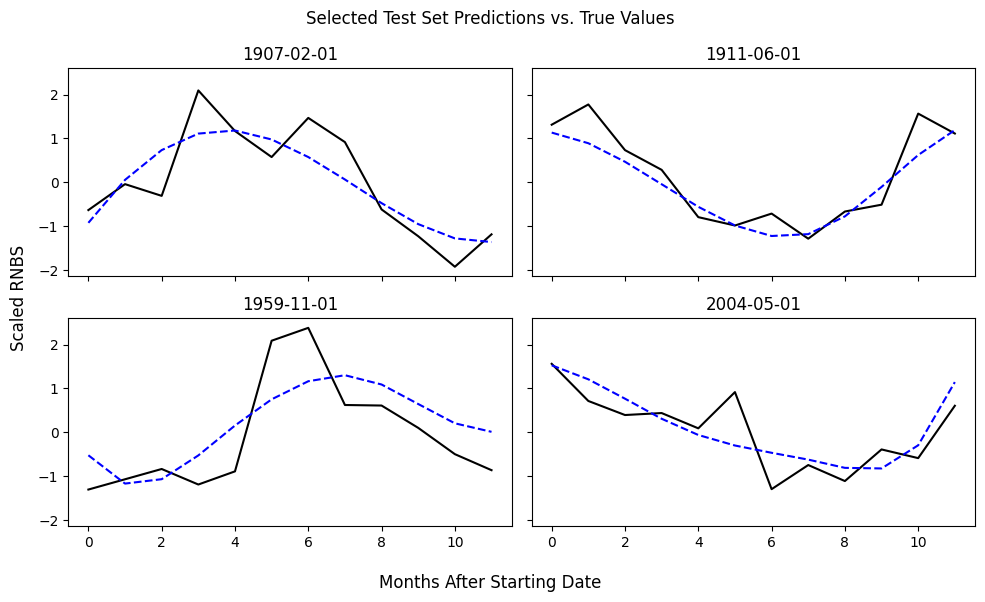

In [18]:
np.random.seed(20250607)
plot_idx = np.sort(rng.choice(len(test_windows), size=4, replace=False))

colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
colors = [
    "#000000",  # black
    "#E69F00",  # orange
    "#56B4E9",  # sky blue
    "#009E73",  # bluish green
]

fig, ax = plt.subplots(figsize=(10, 6), sharex=True, sharey=True, ncols=2, nrows=2)
rng = np.random.default_rng(20250607)
for i, ax_idx in enumerate(ax.flatten()):
    idx = plot_idx[i]

    true, predicted = true_vals[idx, :], pred_grid[idx, :]
    ax_idx.plot(list(range(12)), true, label="True", color="black")
    ax_idx.plot(
        list(range(12)), predicted, linestyle="--", label="Predicted", color="blue"
    )
    ax_idx.set_title(
        np.datetime_as_string(true.coords["test_start_date"].values, unit="D")
    )

fig.supxlabel("Months After Starting Date")
fig.supylabel("Scaled RNBS")
fig.suptitle("Selected Test Set Predictions vs. True Values")
fig.tight_layout()

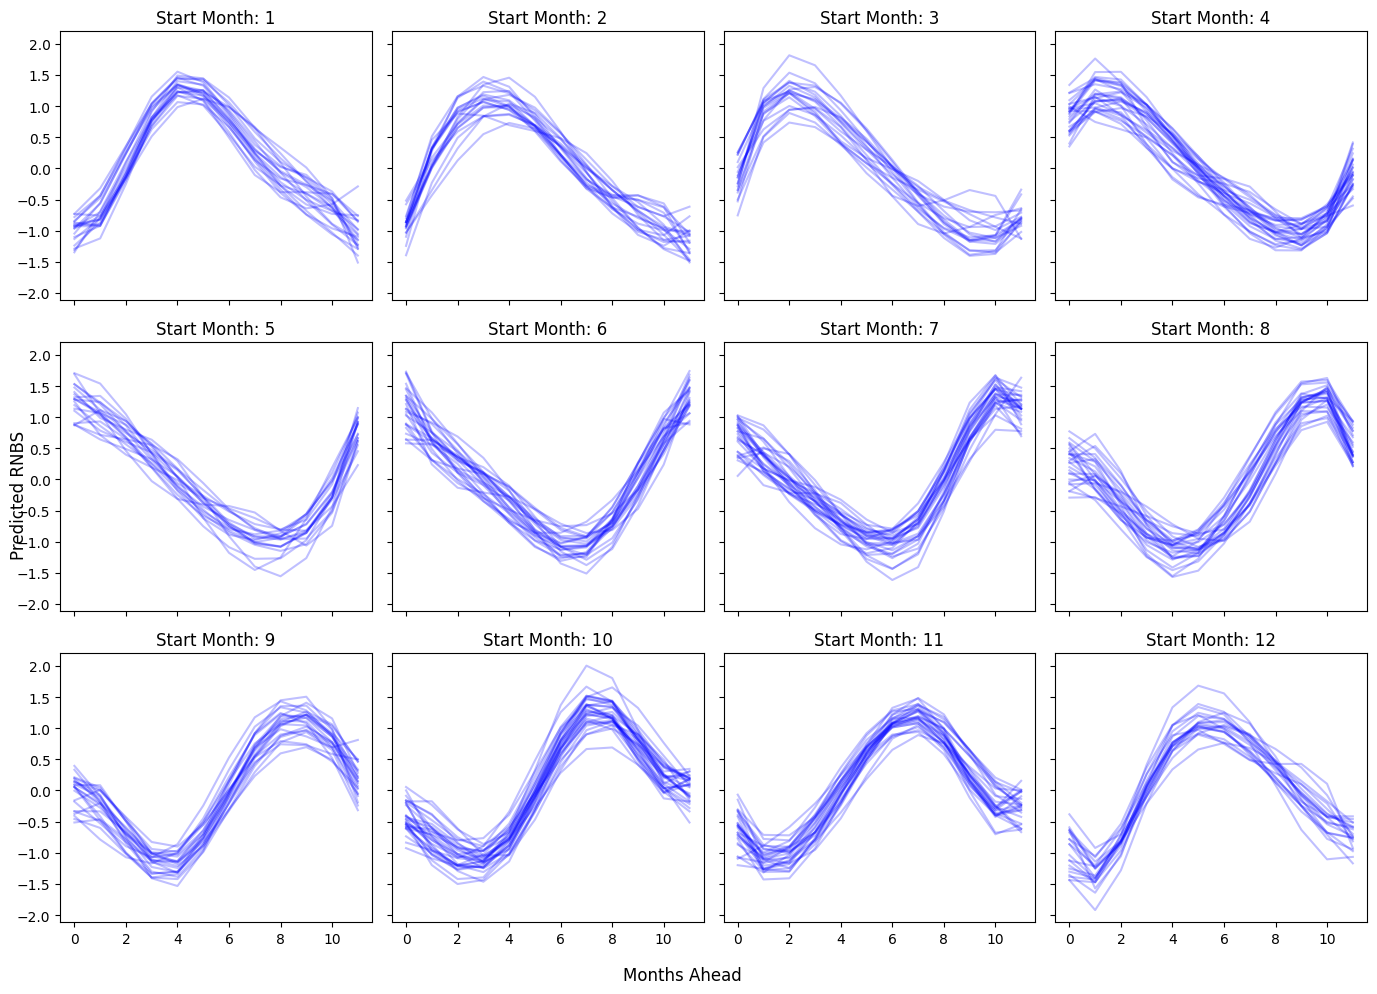

In [19]:
import pandas as pd

predictions = pd.DataFrame(pred_grid)
predictions["pred_dates"] = true_vals.coords["test_start_date"].values


dates = predictions["pred_dates"]
plot_data = predictions.melt(
    id_vars=["pred_dates"], var_name="month_ahead", value_name="predicted_rnbs"
)
plot_data["start_month"] = pd.to_datetime(plot_data["pred_dates"]).dt.month

fig, axes = plt.subplots(3, 4, figsize=(14, 10), sharey=True, sharex=True)
axes = axes.flatten()

for month, ax in zip(range(1, 13), axes):
    df_month = plot_data[plot_data["start_month"] == month]

    if df_month.empty:
        ax.set_title(f"Month {month} (no data)")
        continue

    for date, df in df_month.groupby("pred_dates"):
        ax.plot(df["month_ahead"], df["predicted_rnbs"], alpha=0.25, color="blue")

    ax.set_title(f"Start Month: {month}")

fig.supxlabel("Months Ahead")
fig.supylabel("Predicted RNBS")
plt.tight_layout()
plt.show()

In [20]:
np.sqrt(((true_vals - pred_grid) ** 2).mean())

<xarray.DataArray 'rnbs' ()> Size: 8B
array(0.5715907)
Coordinates:
    lake     <U3 12B 'sup'

## Multiple Lakes

In [21]:
# basis_X = FourierBasis(n_basis=12, domain_range=(0.0, 35.0))
# basis_Y = BSplineBasis(n_basis=6, domain_range=(0.0, 11.0))

fd_X_period = [
    skfda.FDataGrid(
        data_matrix=scaled_train[:, :, i], grid_points=np.arange(36)
    ).to_basis(basis_X)
    for i in range(scaled_train.shape[2])
]

fd_Y_lakes = [
    skfda.FDataGrid(
        data_matrix=scaled_test[:, :, i],
        grid_points=np.arange(12),
    ).to_basis(basis_Y)
    for i in range(scaled_test.shape[2])
]


X_coeff = np.hstack([fd.coefficients for fd in fd_X_period])
Y_coeff = np.hstack([fd.coefficients for fd in fd_Y_lakes])


train_x, test_x, train_y, test_y, train_windows, test_windows = train_test_split(
    X_coeff, Y_coeff, training_windows, test_size=0.2, random_state=42
)

print(train_x.shape)


# model = MLPRegressor(hidden_layer_sizes=(50, 25), max_iter=5000, random_state=42, learning_rate_init=0.01, learning_rate='adaptive')
model = SkRidge(alpha=0.5)
model.fit(train_x, train_y)

(1143, 76)


,alpha,0.5
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


In [22]:
y_coefficients = model.predict(test_x)

y_coeff_matrix = y_coefficients.reshape(-1, basis_Y.n_basis, scaled_test.shape[2])


lake_fns = np.stack(
    [
        skfda.representation.basis.FDataBasis(
            basis=basis_Y, coefficients=y_coeff_matrix[:, :, i]
        )
        .to_grid(np.arange(12))
        .data_matrix[:, :, 0]
        for i in range(4)
    ],
    axis=2,
)

lake_fns.shape

(286, 12, 4)

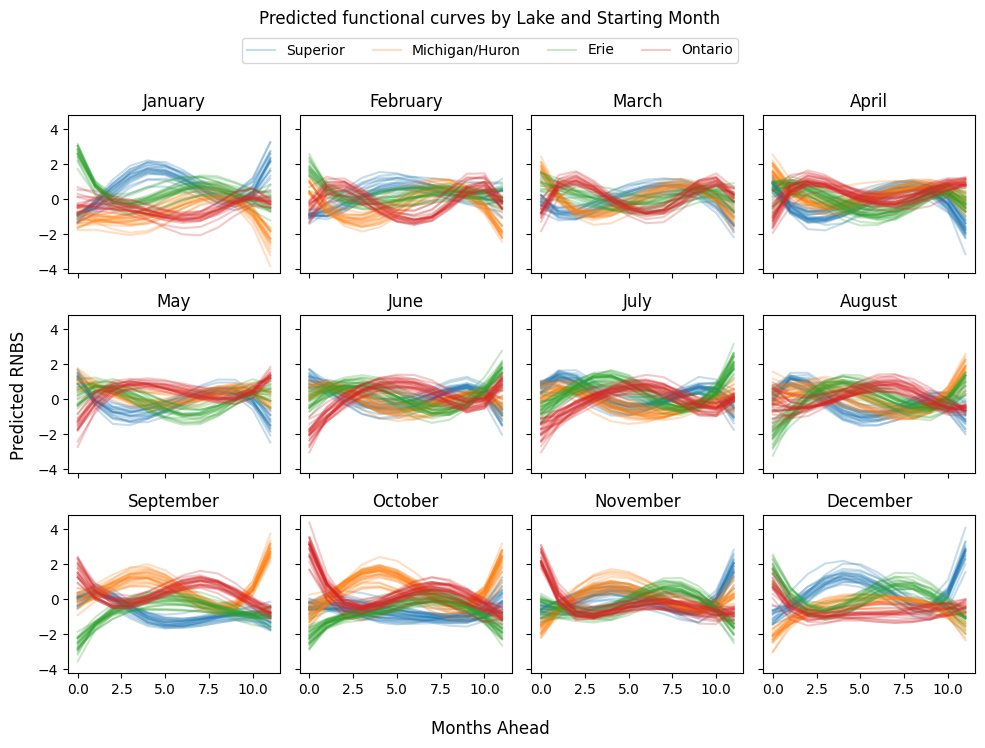

In [ ]:
# fixed colors for each lake
lake_colors = {
    "Superior": "#1f77b4",
    "Michigan/Huron": "#ff7f0e",
    "Erie": "#2ca02c",
    "Ontario": "#d62728",
}

months = {
    1: "January",
    2: "February",
    3: "March",
    4: "April",
    5: "May",
    6: "June",
    7: "July",
    8: "August",
    9: "September",
    10: "October",
    11: "November",
    12: "December",
}

fig, axes = plt.subplots(3, 4, figsize=(10, 7), sharey=True, sharex=True)
axes = axes.flatten()

for lake_idx, lake in enumerate(lake_colors.keys()):
    color = lake_colors[lake]

    predictions = pd.DataFrame(lake_fns[:, :, lake_idx])
    predictions["pred_dates"] = true_vals.coords["test_start_date"].values

    plot_data = predictions.melt(
        id_vars=["pred_dates"], var_name="month_ahead", value_name="predicted_rnbs"
    )
    plot_data["start_month"] = pd.to_datetime(plot_data["pred_dates"]).dt.month

    # loop over months and axes
    for month, ax in zip(range(1, 13), axes):
        df_month = plot_data[plot_data["start_month"] == month]

        if df_month.empty:
            ax.set_title(f"Month {month} (no data)")
            continue

        # draw all curves for this lake + this month in the same color
        for date, df in df_month.groupby("pred_dates"):
            ax.plot(
                df["month_ahead"],
                df["predicted_rnbs"],
                alpha=0.25,
                color=color,
                label=lake,
            )

        ax.set_title(months[month])

fig.supxlabel("Months Ahead")
fig.supylabel("Predicted RNBS")

handles, labels = axes[0].get_legend_handles_labels()
by_label = dict(zip(labels, handles))
fig.legend(
    by_label.values(),
    by_label.keys(),
    loc="upper center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=4,
)
fig.suptitle("Predicted functional curves by Lake and Starting Month", y=1.05)

plt.tight_layout()
plt.show()